In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
REPORTS_DIR = BASE_DIR / 'reports'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Successfully connected to DB! Data streaming from: {DB_PATH}")

Successfully connected to DB! Data streaming from: D:\Programs\bluestock_mf_capstone\data\db\bluestock_mf.db


In [2]:
!pip install -U kaleido

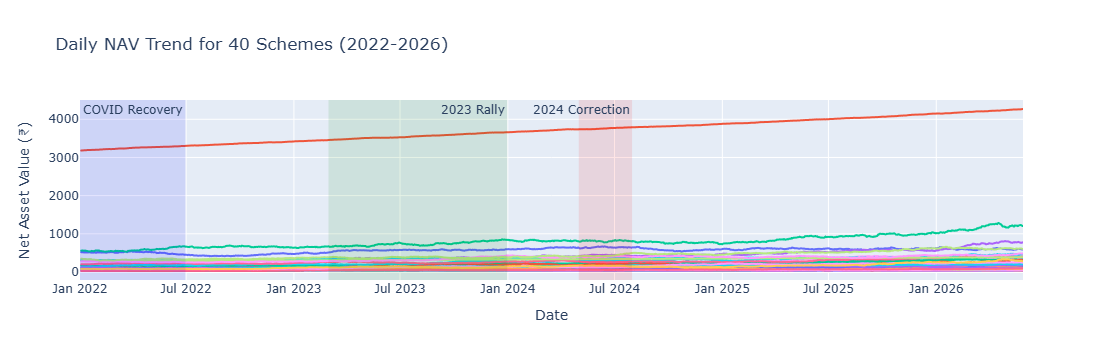

In [3]:
query_nav = """
    SELECT f.nav_date, f.nav, d.scheme_name 
    FROM fact_nav f
    JOIN dim_fund d ON f.amfi_code = d.amfi_code
"""
df_nav = pd.read_sql(query_nav, conn, parse_dates=['nav_date'])

fig = px.line(df_nav, x='nav_date', y='nav', color='scheme_name', 
              title='Daily NAV Trend for 40 Schemes (2022-2026)',
              labels={'nav_date': 'Date', 'nav': 'Net Asset Value (₹)'})

fig.add_vrect(x0="2022-01-01", x1="2022-06-30", fillcolor="blue", opacity=0.1, line_width=0, annotation_text="COVID Recovery")
fig.add_vrect(x0="2023-03-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Rally")
fig.add_vrect(x0="2024-05-01", x1="2024-07-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")

fig.update_layout(showlegend=False) 
fig.show()
fig.write_image(REPORTS_DIR / 'nav_trend.png')

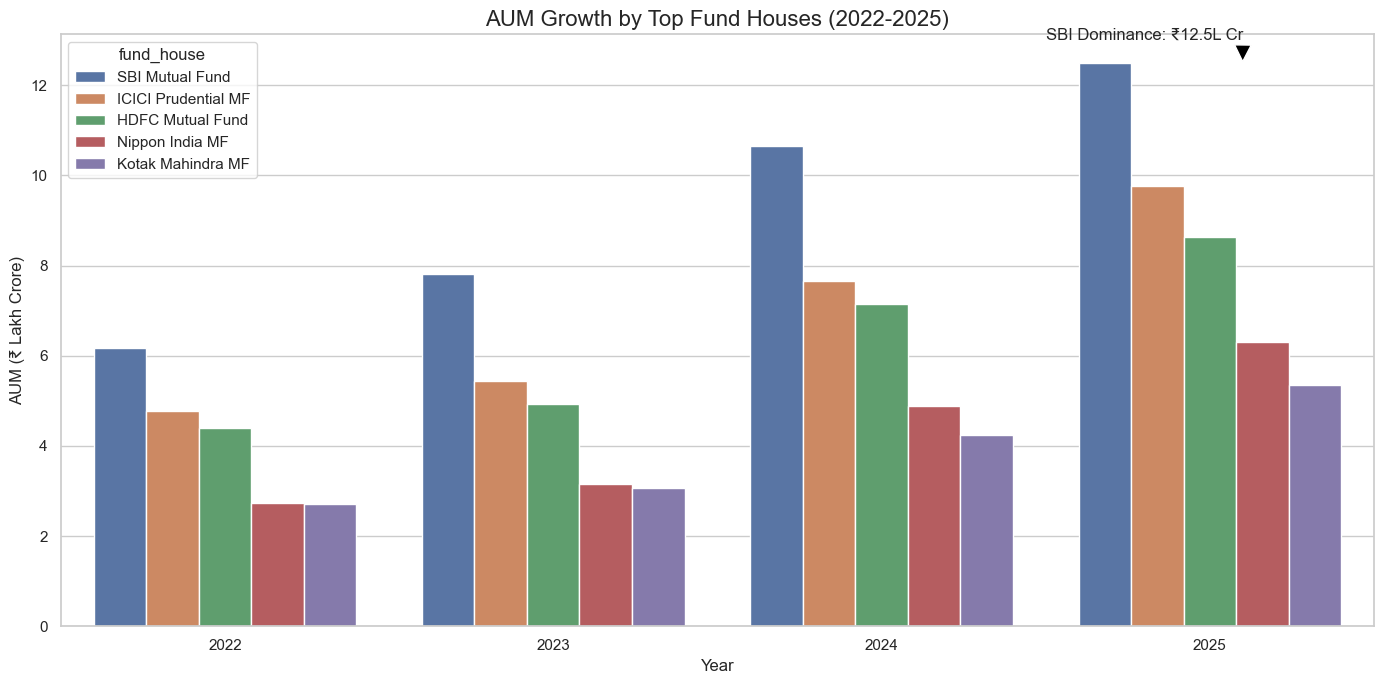

In [4]:
query_aum = "SELECT fund_house, date, aum_crore FROM fact_aum"
df_aum = pd.read_sql(query_aum, conn, parse_dates=['date'])
df_aum['year'] = df_aum['date'].dt.year

df_aum['aum_lakh_crore'] = df_aum['aum_crore'] / 100000

top_amcs = df_aum.groupby('fund_house')['aum_lakh_crore'].max().nlargest(5).index
df_aum_top = df_aum[df_aum['fund_house'].isin(top_amcs)]

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum_top, x='year', y='aum_lakh_crore', hue='fund_house', errorbar=None)
plt.title('AUM Growth by Top Fund Houses (2022-2025)', fontsize=16)
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xlabel('Year')

plt.annotate('SBI Dominance: ₹12.5L Cr', xy=(3.1, 12.5), xytext=(2.5, 13),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.tight_layout()

# Dynamic Save
plt.savefig(REPORTS_DIR / 'aum_growth.png')
plt.show()

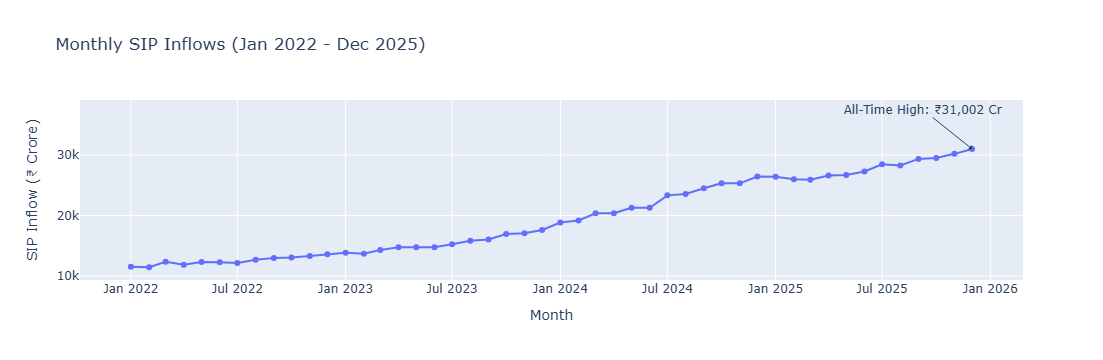

In [5]:
df_sip = pd.read_csv(RAW_DIR / '04_monthly_sip_inflows.csv')
df_sip['month'] = pd.to_datetime(df_sip['month'])

fig = px.line(df_sip, x='month', y='sip_inflow_crore', markers=True,
              title='Monthly SIP Inflows (Jan 2022 - Dec 2025)',
              labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (₹ Crore)'})

fig.add_annotation(x='2025-12-01', y=31002, text="All-Time High: ₹31,002 Cr",
            showarrow=True, arrowhead=1, ax=-50, ay=-40)

fig.show()
fig.write_image(REPORTS_DIR / 'sip_inflows.png')

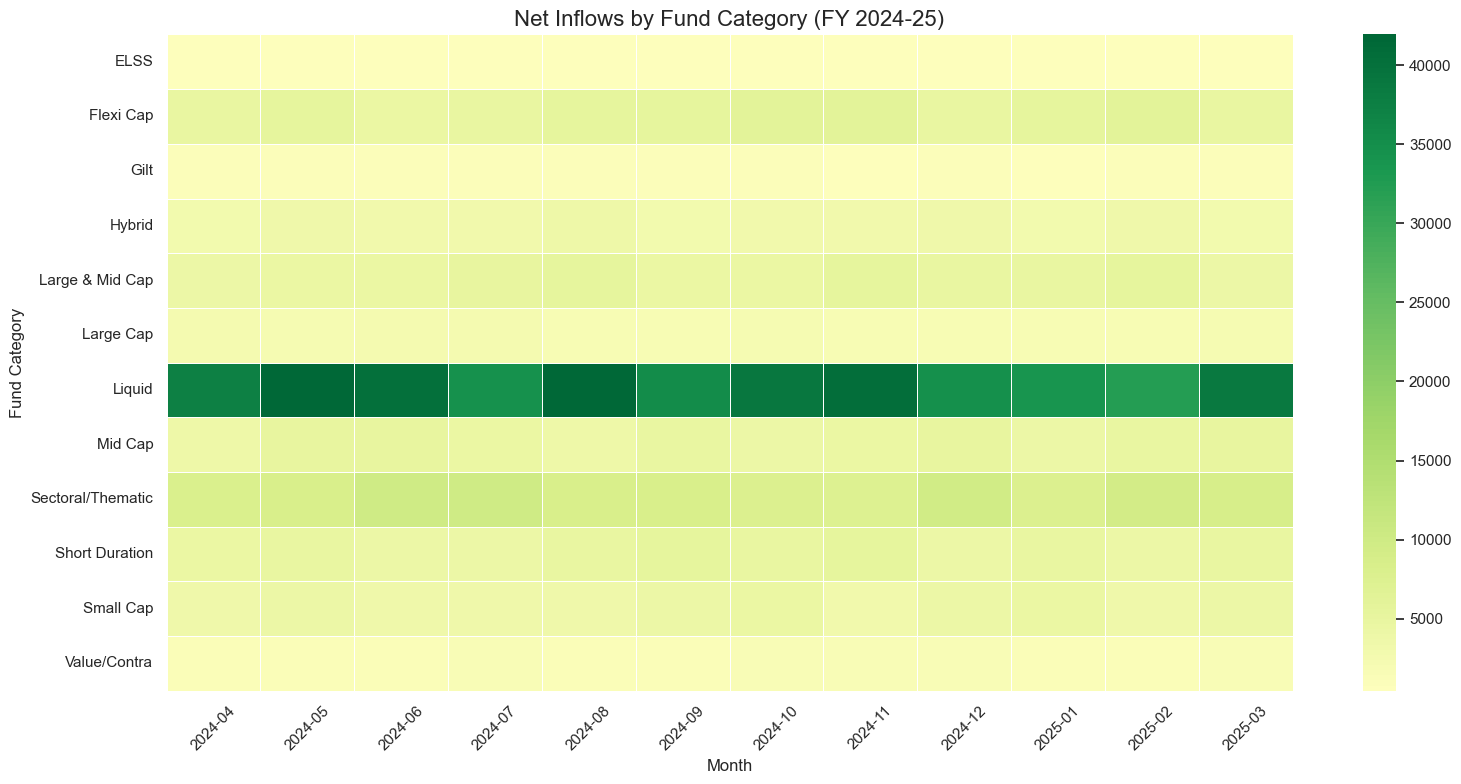

In [6]:
df_cat = pd.read_csv(RAW_DIR / '05_category_inflows.csv')
pivot_cat = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_cat, cmap='RdYlGn', center=0, annot=False, linewidths=.5)
plt.title('Net Inflows by Fund Category (FY 2024-25)', fontsize=16)
plt.ylabel('Fund Category')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(REPORTS_DIR / 'category_heatmap.png')
plt.show()

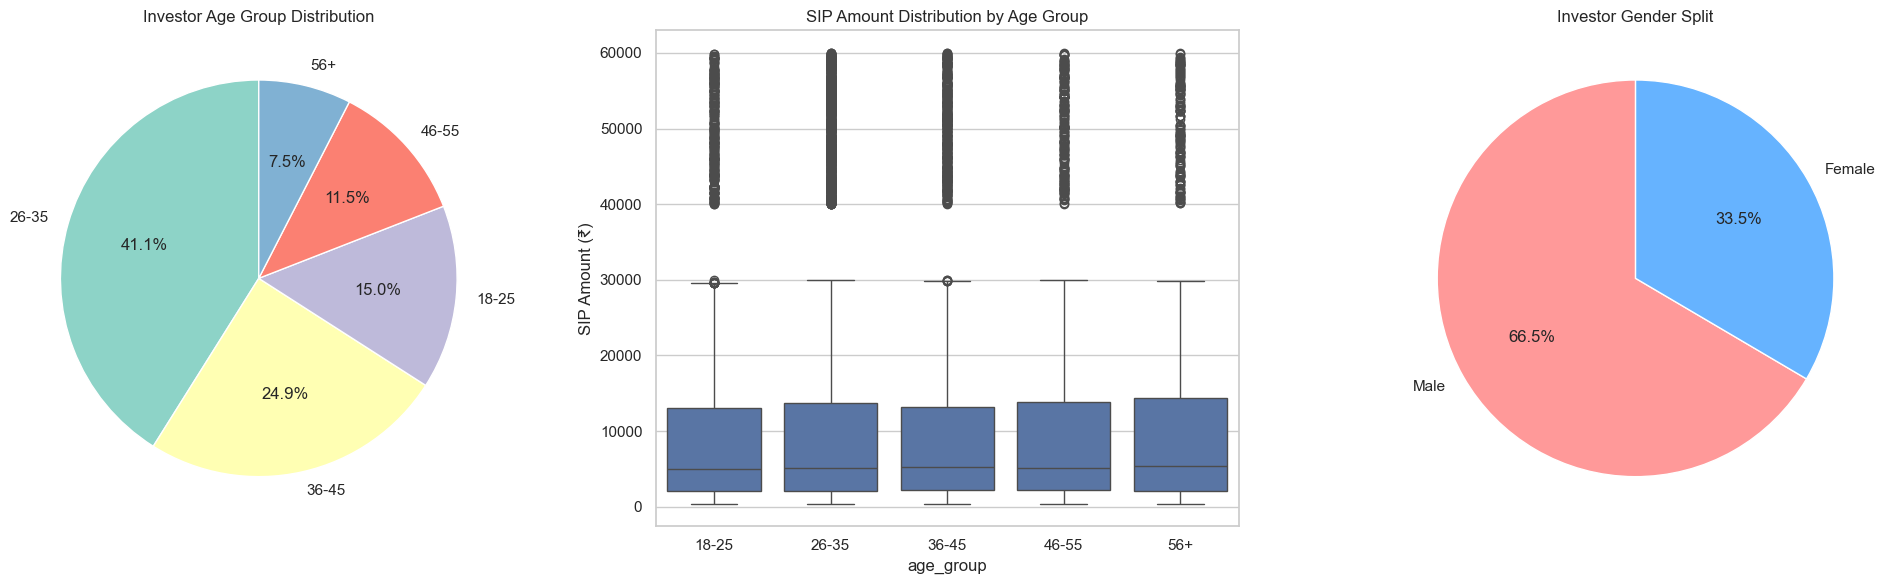

In [7]:
df_txn = pd.read_sql("SELECT * FROM fact_transactions", conn)
sip_txns = df_txn[df_txn['transaction_type'].str.upper() == 'SIP']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

age_counts = df_txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
axes[0].set_title('Investor Age Group Distribution')

sns.boxplot(data=sip_txns, x='age_group', y='amount_inr', ax=axes[1], order=['18-25', '26-35', '36-45', '46-55', '56+'])
axes[1].set_title('SIP Amount Distribution by Age Group')
axes[1].set_ylabel('SIP Amount (₹)')

gender_counts = df_txn['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[2].set_title('Investor Gender Split')

plt.tight_layout()

plt.savefig(REPORTS_DIR / 'demographics.png')
plt.show()

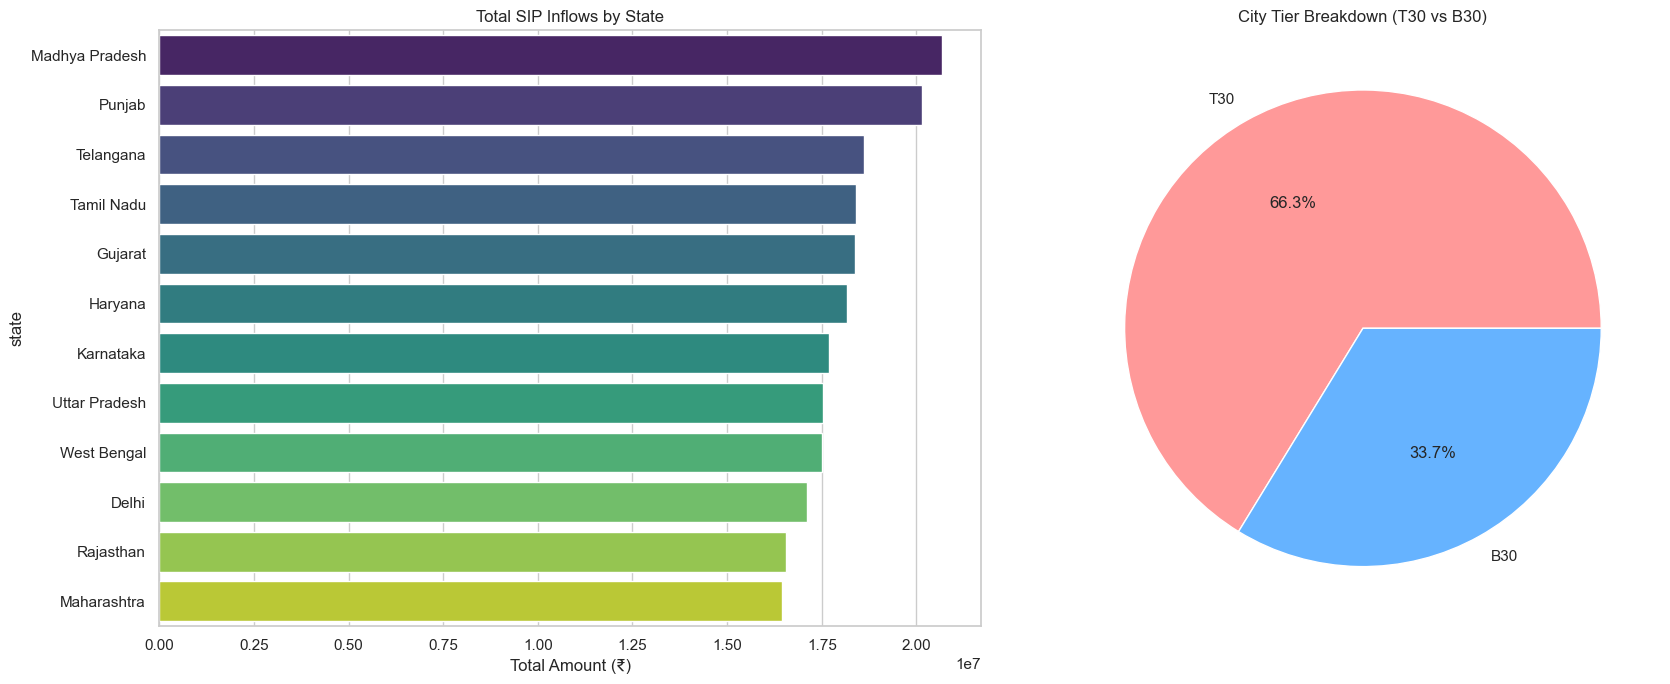

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

state_sip = sip_txns.groupby('state')['amount_inr'].sum().sort_values(ascending=False)
sns.barplot(x=state_sip.values, y=state_sip.index, ax=axes[0], palette='viridis')
axes[0].set_title('Total SIP Inflows by State')
axes[0].set_xlabel('Total Amount (₹)')

tier_counts = df_txn['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('City Tier Breakdown (T30 vs B30)')

plt.tight_layout()

plt.savefig(REPORTS_DIR / 'geo_distribution.png')
plt.show()

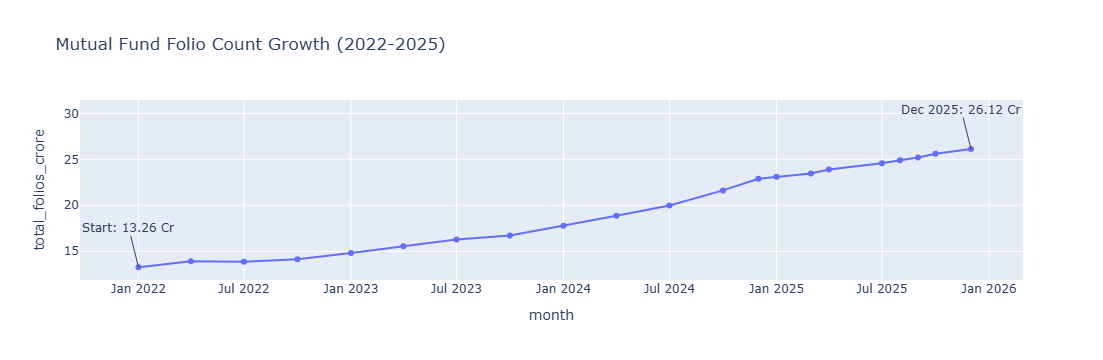

In [9]:
df_folios = pd.read_csv(RAW_DIR / '06_industry_folio_count.csv')
df_folios['month'] = pd.to_datetime(df_folios['month'])

fig = px.line(df_folios, x='month', y='total_folios_crore', markers=True,
              title='Mutual Fund Folio Count Growth (2022-2025)')

fig.add_annotation(x='2022-01-01', y=13.26, text="Start: 13.26 Cr", showarrow=True, ay=-40)
fig.add_annotation(x='2025-12-01', y=26.12, text="Dec 2025: 26.12 Cr", showarrow=True, ay=-40)
fig.show()

fig.write_image(REPORTS_DIR / 'folio_growth.png')

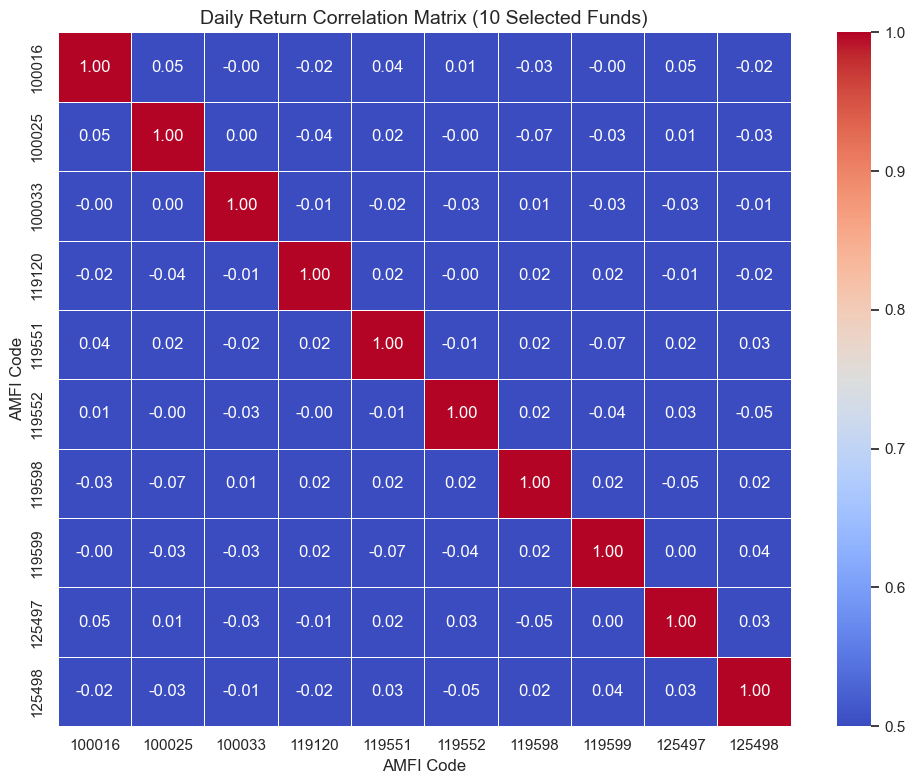

In [10]:
query_corr = """
    SELECT f.nav_date, f.nav, d.amfi_code 
    FROM fact_nav f
    JOIN dim_fund d ON f.amfi_code = d.amfi_code
    WHERE d.amfi_code IN (
        SELECT amfi_code FROM dim_fund LIMIT 10
    )
"""
df_raw = pd.read_sql(query_corr, conn, parse_dates=['nav_date'])
df_raw['nav'] = pd.to_numeric(df_raw['nav'], errors='coerce')

pivot_nav = df_raw.pivot(index='nav_date', columns='amfi_code', values='nav')
pivot_returns = pivot_nav.pct_change().iloc[1:]
corr_matrix = pivot_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=0.5, vmax=1.0) 

plt.title('Daily Return Correlation Matrix (10 Selected Funds)', fontsize=14)
plt.ylabel('AMFI Code')
plt.xlabel('AMFI Code')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_matrix.png')

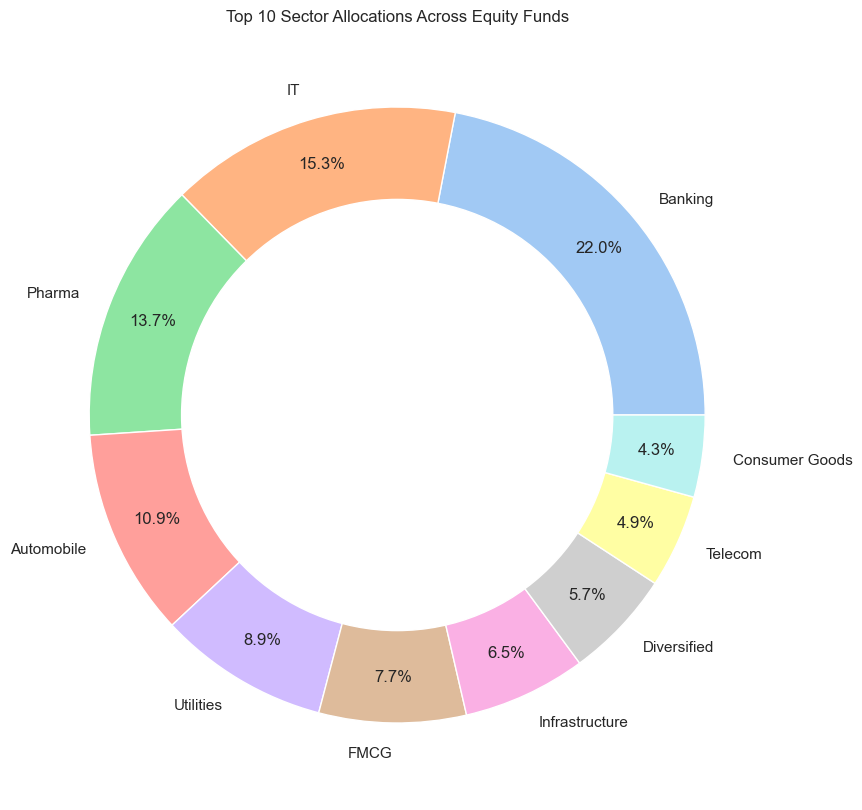

In [11]:
df_holdings = pd.read_csv(RAW_DIR / '09_portfolio_holdings.csv')
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 10))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', pctdistance=0.85, colors=sns.color_palette('pastel'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 10 Sector Allocations Across Equity Funds')

plt.savefig(REPORTS_DIR / 'sector_donut.png')
plt.show()

conn.close()

## Executive Summary: Top 10 Data Insights & Business Implications

* **High NAV Resilience:** Despite sharp 2024 market corrections, historical momentum from the 2023 bull run provided downside protection, with all 40 tracked schemes demonstrating rapid V-shaped recoveries.
* **Severe AUM Consolidation:** The market exhibits high concentration at the top, with SBI Mutual Fund commanding a disproportionate market share, officially breaching the ₹12.5 Lakh Crore AUM threshold in 2025.
* **Inelastic Retail Capital Inflows:** Retail investor sentiment remains largely insulated from short-term market volatility. December 2025 recorded an all-time high of ₹31,002 Crore in SIP inflows, indicating a structural shift in domestic savings behavior.
* **Risk-Off Capital Allocation:** FY 2024-25 net inflows reveal a pivot toward capital preservation, with Liquid funds substantially outpacing traditional equity categories (Large, Mid, Small Cap) in net new assets.
* **SIP Ticket Size Stagnation:** While the 26-35 demographic drives adoption volume (41.1% of base), median SIP ticket sizes remain constrained at ~₹5,000 across *all* age brackets, highlighting a failure to capture proportional wallet share as investors age.
* **Untapped Demographic Segments:** A severe 66.5% to 33.5% male-to-female skew indicates that existing distribution channels are failing to engage female investors, presenting a clear white-space opportunity for targeted acquisition campaigns.
* **Micro-Market Anomalies:** Within the sample cohort, non-traditional hubs (Madhya Pradesh, Punjab) exhibited outsized transaction volumes compared to historically dominant financial centers (Maharashtra, Gujarat), suggesting localized distribution successes or localized data skew.
* **B30 Expansion Headroom:** T30 cities continue to drive the vast majority of inflows. With B30 capital representing only 33.7% of the total, AMC penetration into Tier-2 and Tier-3 geographies remains a massive, unrealized growth vector.
* **Hyper-Growth in Account Volume:** The industry has successfully doubled its active retail footprint, surging from 13.26 Crore folios in Jan 2022 to 26.12 Crore by Dec 2025.
* **Illusion of Diversification:** A heavy sector concentration in Banking (22.0%) and IT (15.3%) has resulted in extreme positive return correlations (>0.85) among top-performing equity funds, exposing multi-fund portfolios to hidden systemic risk.